<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter05_03_%EC%9E%90%EC%A0%84%EA%B1%B0%EC%88%98%EC%9A%94%EC%98%88%EC%B8%A1%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


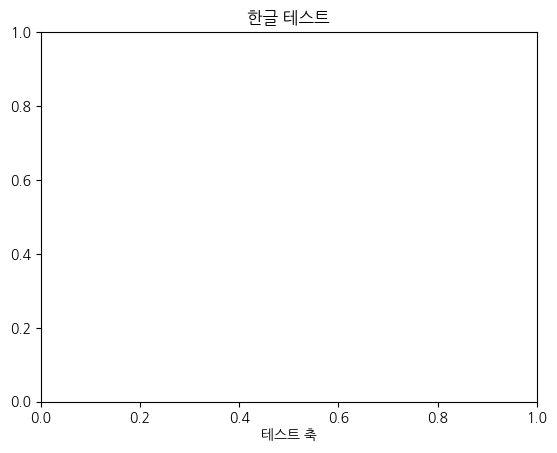

In [1]:
# 구글 드라이브 마운트
from google.colab import drive, files
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# 캐글(kaggle)의 자전거 공유 수요 예측 대회 데이터를 활용 Regression 실습

#
bike_df = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/Bike_Sharing_Demand/bike-sharing-demand/train.csv')
print(bike_df.shape)
bike_df.head(3)

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [5]:
bike_df.info() #datetime 컬럼, 결측치, 수치형, 문자형 컬럼 구분

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
# datetime 컬럼 파싱 + 시간 관련 피처 추출 + 트렌드 피처 생성
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

bike_df['year'] = bike_df.datetime.apply(lambda x: x.year)
bike_df['month'] = bike_df.datetime.apply(lambda x: x.month)
bike_df['day'] = bike_df.datetime.apply(lambda x: x.day)
bike_df['hour'] = bike_df.datetime.apply(lambda x: x.hour)

In [7]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int64         
 13  month       10886 non-null  int64         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
dtypes: datetime64[ns](1), 

In [9]:
# 트렌드 피처 추가
# 모델이 '2012년은 수요가 더 높다'는 성장 트렌드를 못 학습하면 테스트셋을 지속적으로 과소 예측하게 됨
# 서비스 시작 시점(2011년 1월)부터 몇 년째 답안지를 나타내는 연속형 숫자
# -> ' 시간이 지날수록 수요가 선형적으로 증가'하는 트렌드를 표현
# month_index (경과 월 수)
# 2011년 1월 -> month_index = 1
# 2012년 1월 -> month_index = 13
# yaer(범주형)외의 차이: year는 2011, 2012 두 값만 각 연도의 평균 수준만 학습,
# month_index는 1~24 연속값이 있으면 월별 세밀한 성장 곡선 학습 가능
bike_df['month_index'] = (bike_df['year'] - 2011) * 12 + bike_df['month']

# time_index (전체 순서 번호)
# 데이터셋에서 시간 순서대로의 행 번호 (0,1,2,...,10885)
# 시간이 흐를수록 수요가 증가하는 장기 트렌드를 가장 직접적으로 표현하기 위해 인덱스 사용
# 선형 모델에서 특히 효과적: 계수 하나로 전체 성장 기울기를 학습
bike_df['time_index'] = np.arange(len(bike_df))

In [12]:
bike_df.tail(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,month_index,time_index
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,24,10883
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,24,10884
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012,12,19,23,24,10885


In [14]:
# 불필요한 컬럼 삭제
drop_columns = ['datetime','casual','registered']
# 비회원, 회원 대여 횟수 (count 총 대여의 일부), 예측 시점에는 알 수 없으므로 삭제
bike_df.drop(drop_columns, axis=1, inplace=True) # bike_df 자체를 수정


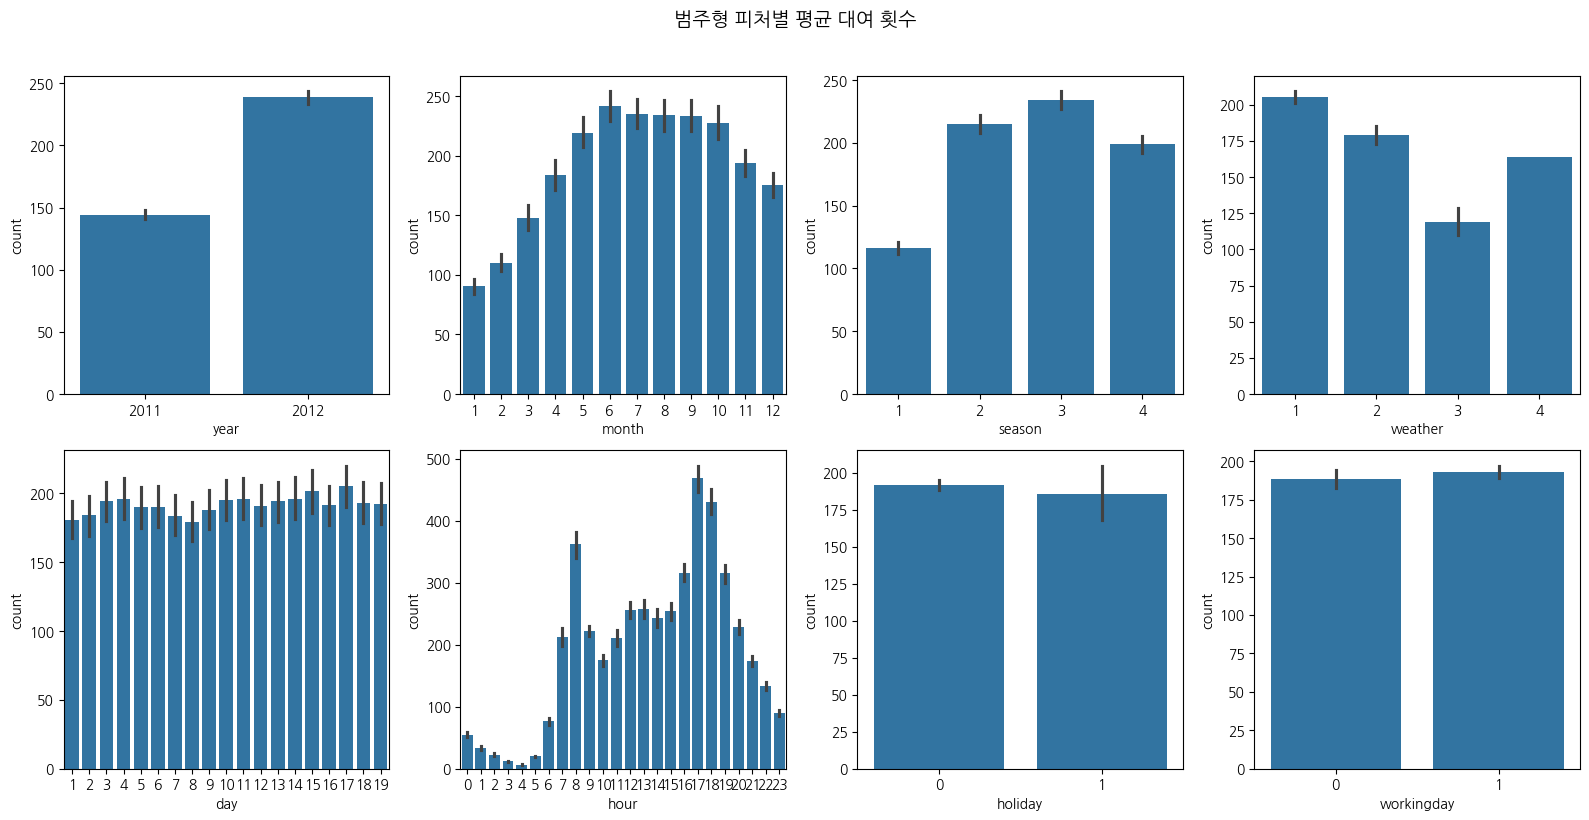

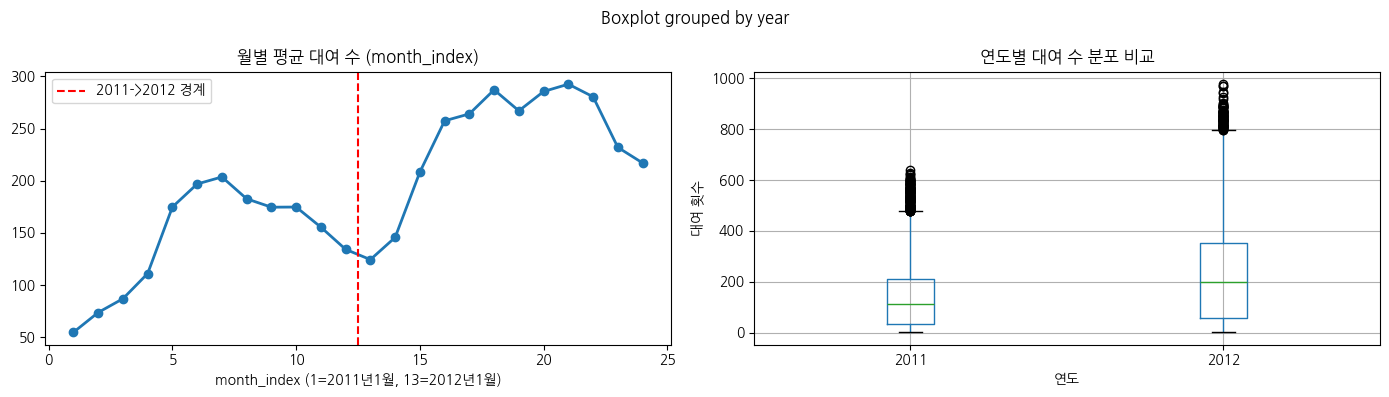

연도별 평균 대여 수:
year
2011    144.223349
2012    238.560944
Name: count, dtype: float64


In [19]:
# 범주형 피처별 자전거 대여 수 시각화 (EDA), 연도별 수요 트렌드 확인
# 범주형 피처별 barplot
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
cat_features = ['year','month','season','weather',
                'day','hour','holiday','workingday']
for i, feature in enumerate(cat_features):
  row = int(i/4)
  col = i % 4
  sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row, col])
plt.suptitle('범주형 피처별 평균 대여 횟수', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 트렌드 피처 시각화
fig, axes = plt.subplots(figsize=(14,4), ncols=2)
# month index별 평균 대여 수
monthly_avg = bike_df.groupby('month_index')['count'].mean()
axes[0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
axes[0].set_title('월별 평균 대여 수 (month_index)')
axes[0].set_xlabel('month_index (1=2011년1월, 13=2012년1월)')
axes[0].axvline(x=12.5, color='red', linestyle='--', label='2011->2012 경계')
axes[0].legend()

# 연도별 박스플롯: 2011 vs 2012 수요 수준 차이 확인
bike_df.boxplot(column='count', by='year',ax=axes[1])
axes[1].set_title('연도별 대여 수 분포 비교')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('대여 횟수')
plt.tight_layout()
plt.show()

print('연도별 평균 대여 수:')
print(bike_df.groupby('year')['count'].mean())

In [24]:
# 평가 지표 함수 정의 (RMSLE, RMSE, MAE)
# RMSLE (Root Mean Squared Log Error)
# 로그 스케일에서 오차를 측정하므로, 작은 값과 큰 값의 '상대적 오차'를 동등하게 평가
# '50% 틀렸다'는 것을 실제 값 크기에 관계없이 유사하게 패널티 부여
from sklearn.metrics import mean_squared_error, mean_absolute_error # 추가

def rmsle(y, pred):
  log_y = np.log1p(y)
  log_pred = np.log1p(pred)
  squared_error = (log_y - log_pred) ** 2
  rmsle = np.sqrt(np.mean(squared_error))
  return rmsle



# RMSE (Root Mean Squared Error)
def rmse(y, pred):
  return np.sqrt(mean_squared_error(y, pred))
# 큰 오차를 제곱으로 더 크게 벌주므로 이상치에 민감, 원본 단위(대여 횟수)로 해석 가능

# 새 평가지표를 한 번에 출력
def evaluate_regr(y, pred):
  rmsle_val = rmsle(y, pred)
  rmse_val = rmse(y, pred)
  mae_val = mean_absolute_error(y, pred) # MAE (Mean Absolute Error): 절대 오차의 평균, 이상치에 가장 덜 민감한 지표
  print('RMSLE: {0:.3f}, RMSE: {1:.3F}, MAE: {2:.3F}'.format(
      rmsle_val, rmse_val, mae_val
  ))

In [22]:
# [Step 1] 시간순 80/20 분할 + 기본 LearningRefression -> Baseline_code
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import make_scorer

# 피처(X)와 타깃(y) 분리
y_target = bike_df['count']
X_features = bike_df.drop(['count'], axis=1, inplace=False)

# 시계열 데이터 분할: 시간 순서대로 80:20
split_idx = int(len(X_features) * 0.8)

X_train_full = X_features.iloc[:split_idx]
X_test       = X_features.iloc[split_idx:]
y_train_full = y_target.iloc[:split_idx]
y_test       = y_target.iloc[split_idx:]

print(f'전체 데이터: {len(X_features)}행')
print(f'훈련셋 (80%): {len(X_train_full)}행')
print(f'테스트셋 (20%): {len(X_test)}행')
print('훈련셋 연도 분포:')
print(bike_df.iloc[:split_idx]['year'].value_counts().sort_index())
print('테스트셋 연도 분포:')
print(bike_df.iloc[split_idx:]['year'].value_counts().sort_index())

전체 데이터: 10886행
훈련셋 (80%): 8708행
테스트셋 (20%): 2178행
훈련셋 연도 분포:
year
2011    5422
2012    3286
Name: count, dtype: int64
테스트셋 연도 분포:
year
2012    2178
Name: count, dtype: int64


In [25]:
# 기본 LinearRegression (로그 변환 없이) -> 기준선 없이
lr_reg = LinearRegression()
lr_reg.fit(X_train_full, y_train_full)
pred = lr_reg.predict(X_test)
evaluate_regr(y_test, pred)

RMSLE: 1.243, RMSE: 183.966, MAE: 141.547
